# **Codes to lecture 7.**


This notebook includes codes on such topics as:

- Convolution in Python
- ANN for CIFAR-10 classification task
- CNN for CIFAR-10 mclassification task

It is based on

 - https://miroslawmamczur.pl/jak-dzialaja-konwolucyjne-sieci-neuronowe-cnn/
 - https://www.tensorflow.org/tutorials/images/cnn?hl=en

>[Codes to lecture 7.](#scrollTo=-cdRoLblGnY8)

>[7.0. Load and show image](#scrollTo=_4mJ9Kh8O6cq)

>[7.1. Convolution using convolve2d()](#scrollTo=BI53y3nEPD-c)

>>>[7.1.1 Examples of kernels used in the convolutions](#scrollTo=0rQKfxOuPRKD)

>[7.3. Datest CIFAR-10](#scrollTo=azQq7CwCX8jG)

>[7.4. Artificial Neural network (ANN) for CIFAR-10 classification task](#scrollTo=NAM3YKS_SiUk)

>[7.5. Convolutional Neural Network (CNN) for CIFAR-10 classification task](#scrollTo=JLGXXxn6PeEL)

>[7.6 Further improvements.](#scrollTo=ggt81APkHnx-)



# 7.0. Load and show image

In [1]:
# import packages
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# load image and check shape
input_image = plt.imread('./pwr.jpg')
print(f'Input shape: {input_image.shape}')

Input shape: (222, 362, 3)


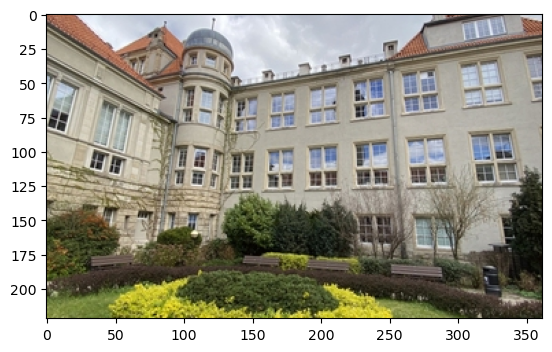

In [3]:
# show image wmat.jpg
plt.imshow(input_image)

In [4]:
# function changing colors to "gray-scale"
def rgb2gray(rgb):
    #r, g, b = rgb[:,:,0], rgb[:,:,1], rgb[:,:,2]
    #return 0.299 * r + 0.587 * g + 0.114 * b
    return np.dot(rgb[...,:3], [0.299, 0.587, 0.114])

In [5]:
# change image [input_image] to "gray-scale"
input_image = rgb2gray(input_image)

# and check shape of the image
print(f'Input shape: {input_image.shape}')

Input shape: (222, 362)


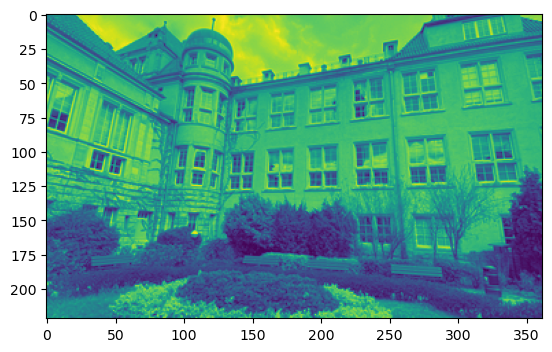

In [6]:
# show the image wmat.jpg in "gray-scale"
plt.imshow(input_image)

# 7.1. Convolution using convolve2d()

In [7]:
# load  module
from scipy.signal import convolve2d

# function calculating the convolution of the kernel [kernel] with image [img]
def apply_kernel_to_image(img, kernel, title=''):

    feature = convolve2d(img, kernel, boundary='symm', mode='same')

    # Plot
    fig = plt.figure(figsize=(20, 10))
    ax1 = fig.add_subplot(1, 2, 1)
    ax1.imshow(img, 'gray')
    ax1.set_title('Input image', fontsize=15)
    ax1.set_xticks([])
    ax1.set_yticks([])

    ax2 = fig.add_subplot(1, 2, 2)
    ax2.imshow(feature, 'gray')
    ax2.set_title(f'Image after convolution with given kernel ({title})', fontsize=15)
    ax2.set_xticks([])
    ax2.set_yticks([])
    plt.show()

### 7.1.1 Examples of kernels used in the convolutions

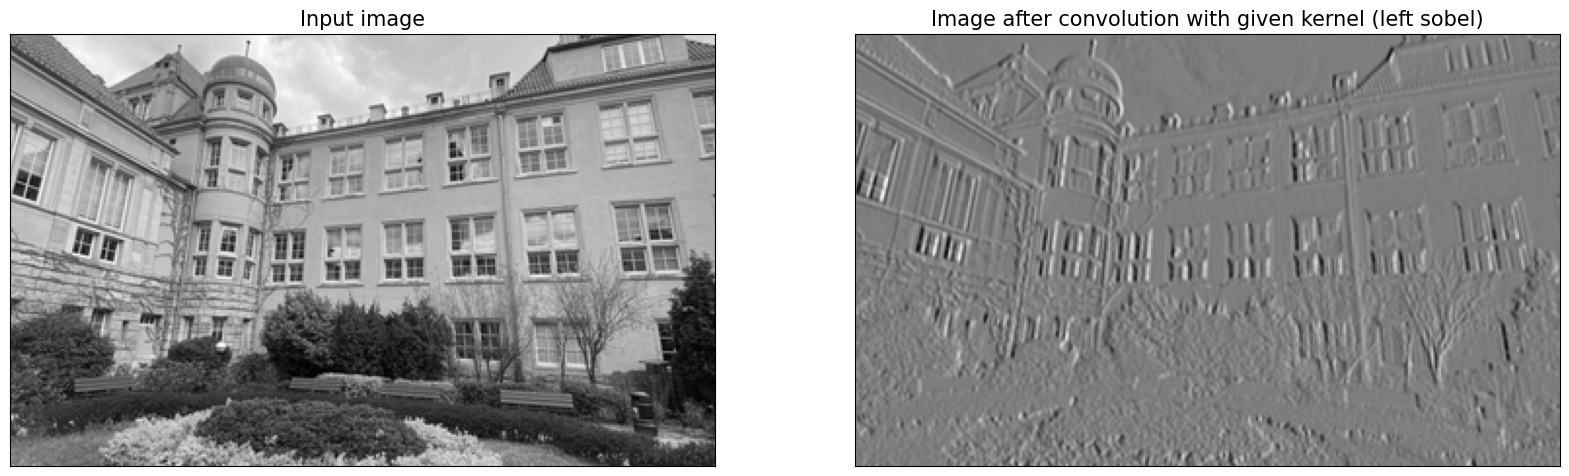

In [8]:
# Example ot the kernel - left sobel
sobel_left = np.array([
    [1, 0, -1],
    [2, 0, -2],
    [1, 0, -1]])

apply_kernel_to_image(input_image, sobel_left, 'left sobel')

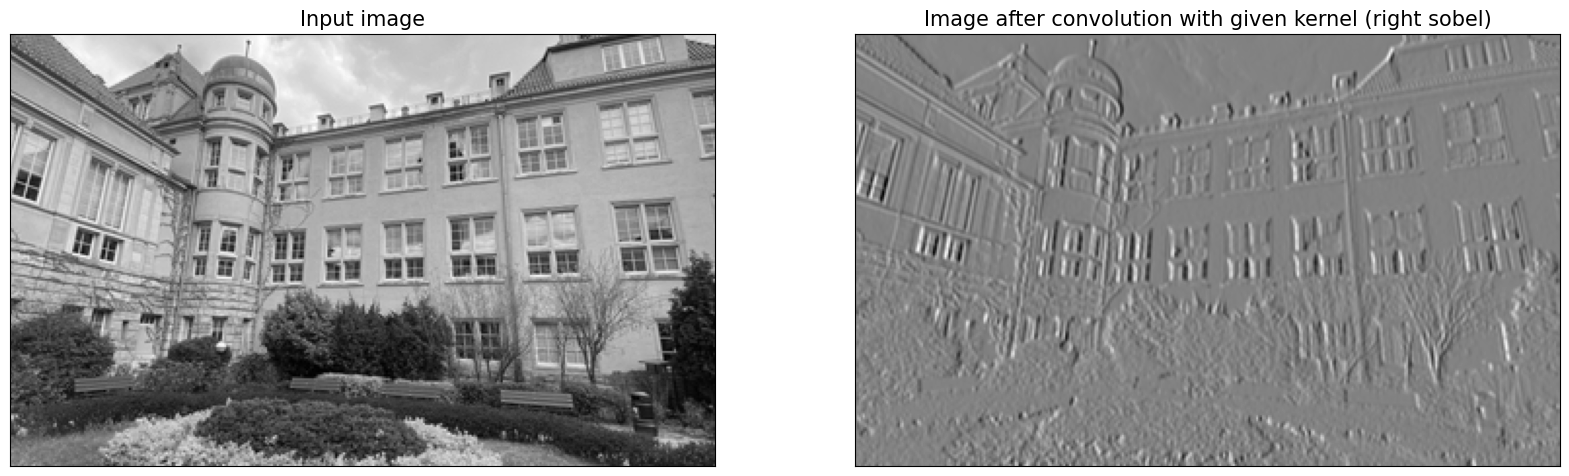

In [9]:
# Example ot the kernel - right sobel
sobel_right = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]])

apply_kernel_to_image(input_image, sobel_right, 'right sobel')

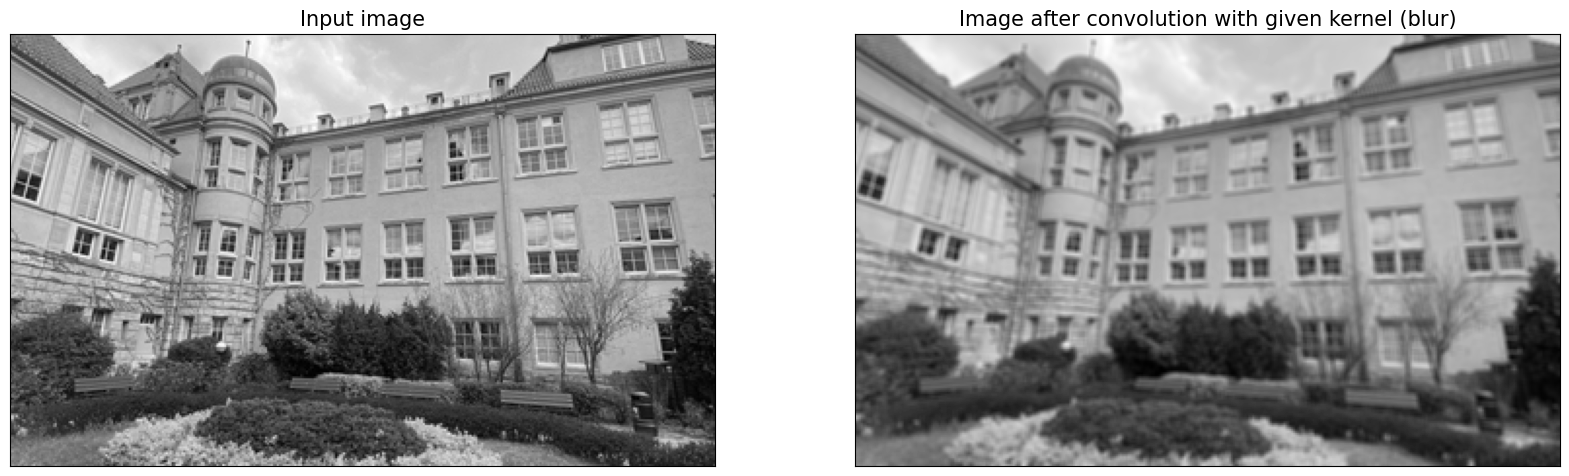

In [10]:
# Example ot the kernel - blur
blur = np.array([
    [0.01, 0.01, 0.01],
    [0.01, 0.01, 0.01],
    [0.01, 0.01, 0.01]])

apply_kernel_to_image(input_image, blur, 'blur')

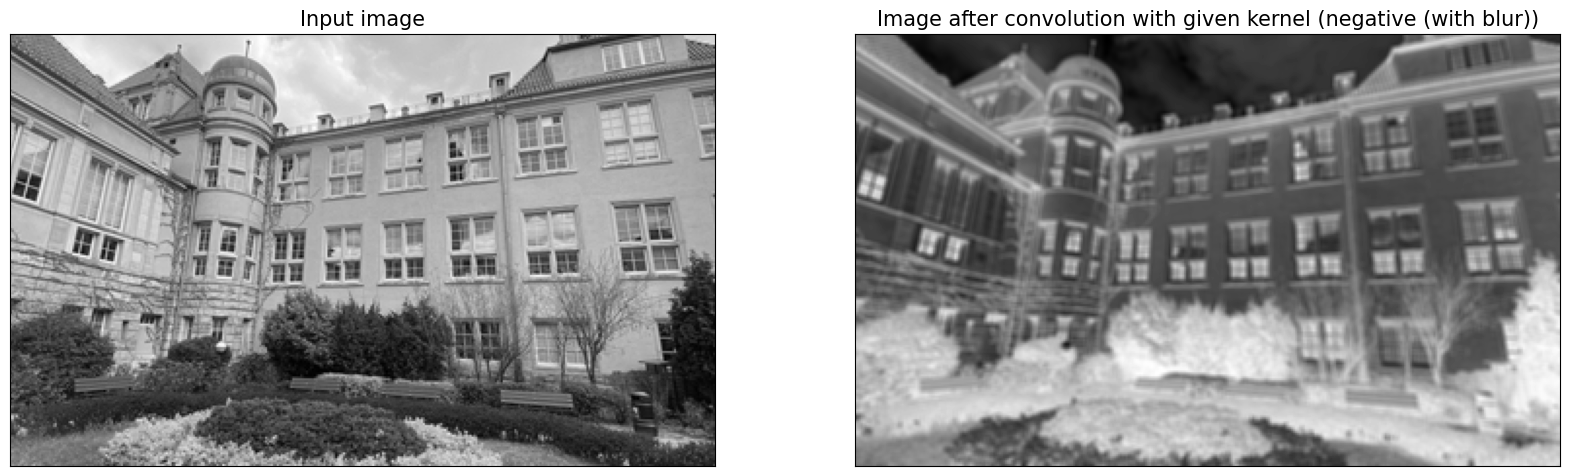

In [11]:
# Example ot the kernel - negative
negatyw = np.array([
    [-1, -1, -1],
    [-1, -1, -1],
    [-1, -1, -1]])

apply_kernel_to_image(input_image, negatyw, 'negative (with blur)')

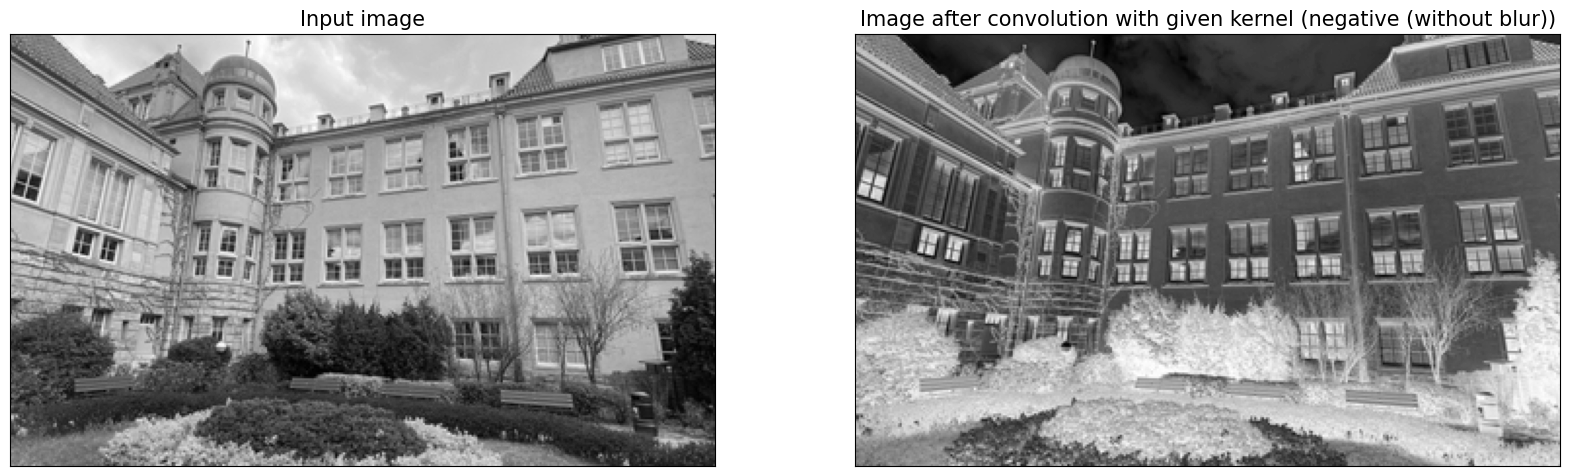

In [12]:
# Example ot the kernel - negative
negatyw1 = np.array([
    [0, 0, 0],
    [0, -1, 0],
    [0, 0, 0]])

apply_kernel_to_image(input_image, negatyw1, 'negative (without blur)')

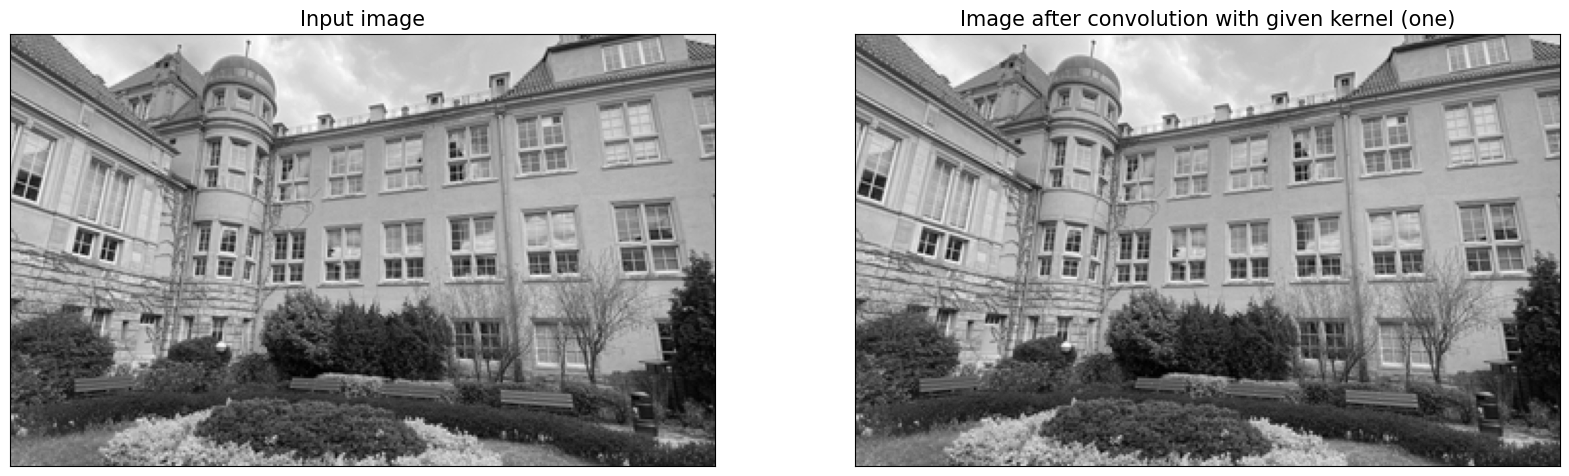

In [13]:
# Example ot the kernel - one
one1 = np.array([
    [0, 0, 0],
    [0, 1, 0],
    [0, 0, 0]])

apply_kernel_to_image(input_image, one1, 'one')

In [14]:
# another examples of kernels - see e.g. https://en.wikipedia.org/wiki/Kernel_(image_processing)

# 7.3. Datest CIFAR-10

In [1]:
# import modules
import tensorflow as tf
from tensorflow.keras import datasets
import matplotlib.pyplot as plt

2025-12-14 12:32:54.298794: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-12-14 12:32:54.378678: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-12-14 12:32:57.251111: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
# download and train-test split of the dataset CIFAR10
(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()

# normalize
train_images, test_images = train_images / 255.0, test_images / 255.0

In [3]:
train_labels.shape

(50000, 1)

In [4]:
# class names in CIFAR-10
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']


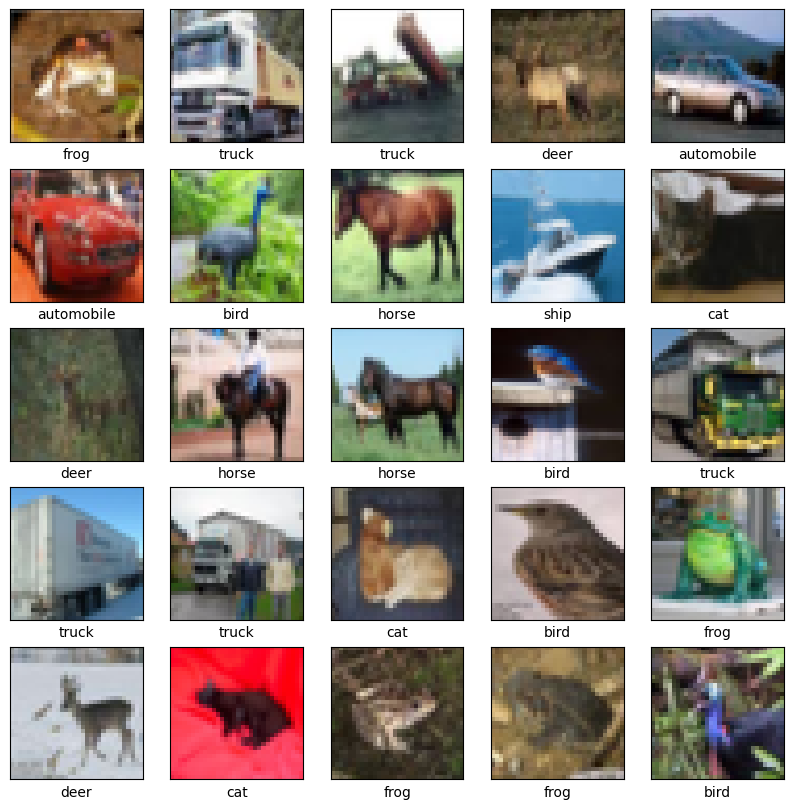

In [5]:
# 25 examples of the images from dataset CIFAR-10
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[i])
    plt.xlabel(class_names[train_labels[i][0]])
plt.show()

# 7.4. Artificial Neural network (ANN) for CIFAR-10 classification task

In [6]:
# import modules
import tensorflow as tf
import keras
from keras import layers

In [7]:
# import modules from keras
from keras.models import Sequential
from keras.layers import Dense, Flatten

# Bulding Neural Network model [ann] with 3 dense layers
ann = Sequential()
ann.add(Flatten(input_shape=(32, 32, 3)))
ann.add(Dense(128, activation="relu"))
ann.add(Dense(64, activation="relu"))
ann.add(Dense(10))

/home/dawid/.local/lib/python3.12/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
2025-12-14 12:33:12.732892: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


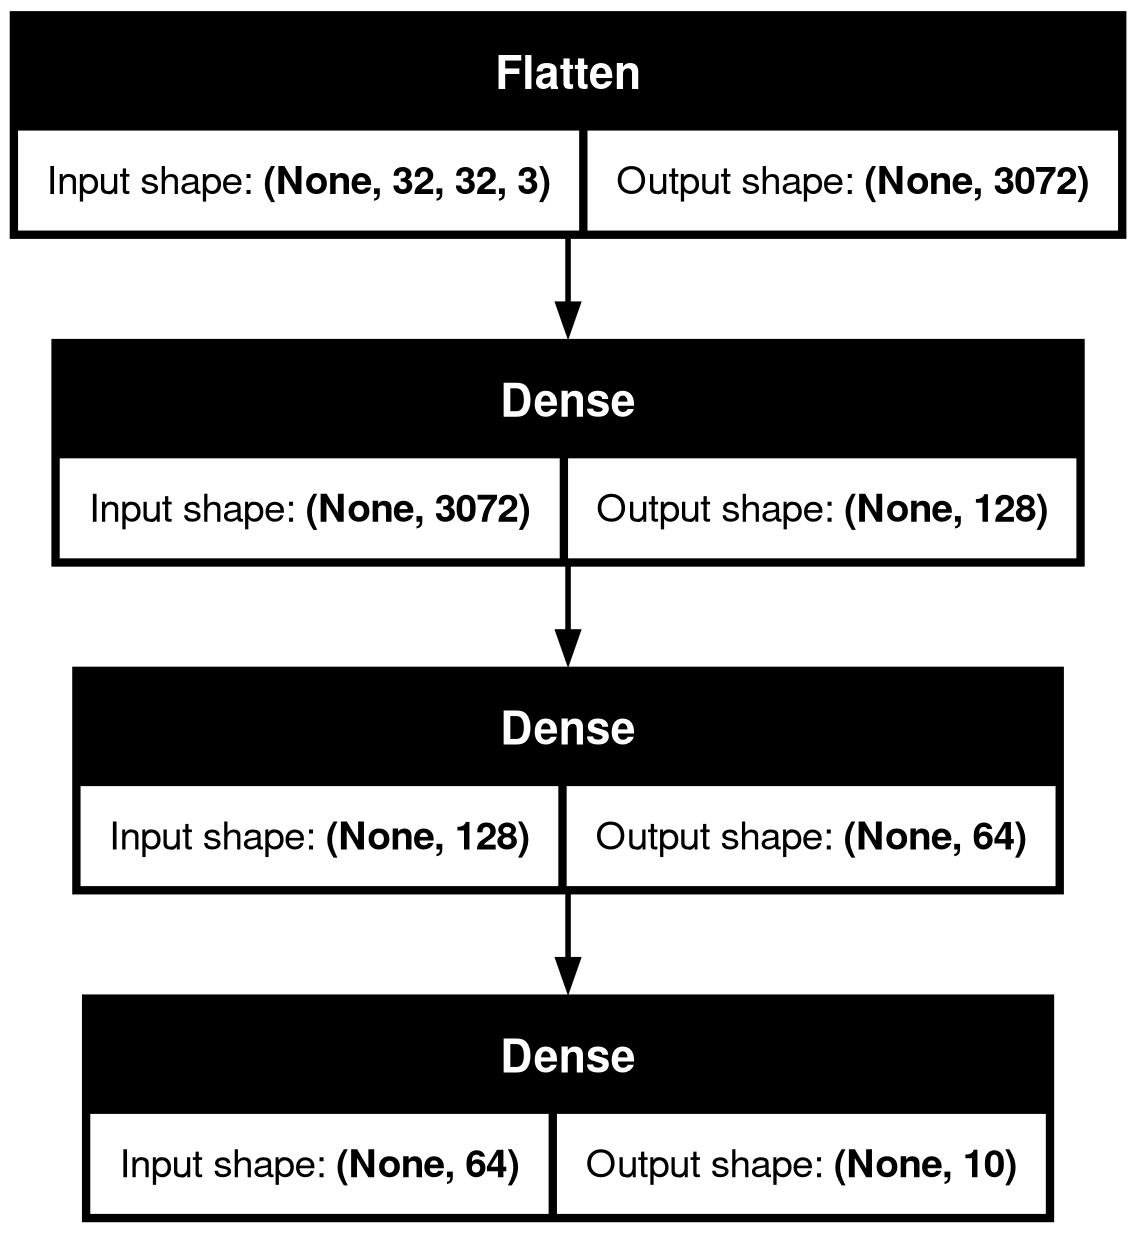

In [8]:
# import module to plot graph of the model [ann]
from keras.utils import plot_model

# model graph [ann]
keras.utils.plot_model(ann,
                       "my_first_model_with_shape_info.png",
                       show_shapes=True)

In [9]:
# summary of the architecture for model [ann]
ann.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       393,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 402,250 (1.53 MB)

 Trainable params: 402,250 (1.53 MB)

 Non-trainable params: 0 (0.00 B)

Note that

$$\text{number_of_parameters = (dim_previous_layer + 1)} \ \cdot \ \text{dim_current_layer}$$

e.g.
$$393 344 = (3072 + 1) \cdot 128$$
$$8 256  = (128 + 1) \cdot 64$$
$$650 = (64 + 1) \cdot 10$$

In [10]:
# model compilation [ann]
ann.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

In [14]:
# model training [ann]
history_ann = ann.fit(train_images, train_labels,
                      epochs=2, batch_size=64,
                      validation_split=0.1)

Epoch 1/2


2025-12-14 12:33:58.136378: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 552960000 exceeds 10% of free system memory.


704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.3939 - loss: 1.6924 - val_accuracy: 0.3708 - val_loss: 1.7645
Epoch 2/2
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.4117 - loss: 1.6416 - val_accuracy: 0.4116 - val_loss: 1.6629


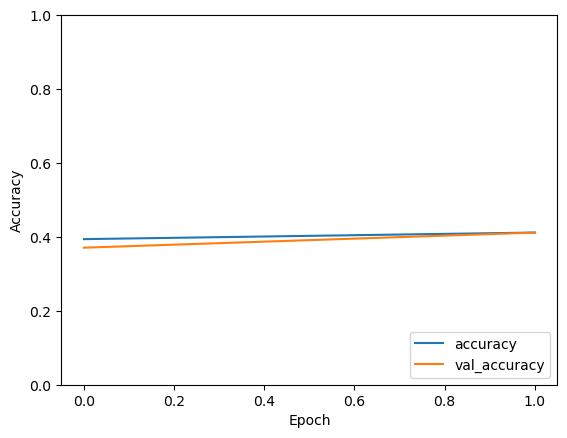

In [15]:
# Plot of learning curves for model [ann]
plt.plot(history_ann.history['accuracy'], label='accuracy')
plt.plot(history_ann.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0, 1])
plt.legend(loc='lower right')

In [16]:
# loss function and accuracy on the test set for model [ann]
test_loss_ann, test_acc_ann = ann.evaluate(test_images,  test_labels, verbose=2)

313/313 - 1s - 3ms/step - accuracy: 0.4161 - loss: 1.6430


In [17]:
# accuracy on the test set for model [ann]
print(test_acc_ann)

0.41609999537467957


In [18]:
# saving model [ann]
ann.save("path_to_my_model.keras")

# deleting model [ann]
#del ann

# loading model [ann] from file
model = keras.models.load_model("path_to_my_model.keras")

# 7.5. Convolutional Neural Network (CNN) for CIFAR-10 classification task

In [19]:
# import modules from keras
from tensorflow.keras import layers, models

In [20]:
# Building CNN with 1 convolutional layer and 1 pooling layer
cnn = models.Sequential()
cnn.add(layers.Conv2D(24, (3, 3), activation='relu', input_shape=(32, 32, 3)))
cnn.add(layers.MaxPooling2D((2, 2)))
cnn.add(layers.Flatten())
cnn.add(layers.Dense(10))

/home/dawid/.local/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [21]:
# summary of architecture of the created model [cnn]
cnn.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 24)     │           672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 24)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 5400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │        54,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 54,682 (213.60 KB)

 Trainable params: 54,682 (213.60 KB)

 Non-trainable params: 0 (0.00 B)

Notice that

$$
\text{number_of_parameters} = \text{(kernel_dim_1} \cdot \text{kernel_dim_2} \cdot \text{number_of_channels + 1)} \cdot \text{number_of_kernels}
$$
and
$$
\text{number_of_channels} = 3 \ \text{or} \  1 \text{(RGB or Gray-scale)}$$
while
$$
\text{kernel_dim_1} = 3 \quad \text{and} \quad  \text{kernel_dim_2} = 3 \quad \text{because we use kernels of size} \ (3,3)$$
e.g.
$$672 = (3 \cdot 3 \cdot 3 + 1) \cdot 24$$

In [22]:
# model compilation [cnn]
cnn.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

In [24]:
# model training [cnn]
history_cnn = cnn.fit(train_images, train_labels,
                     epochs=2, batch_size=32,
                     validation_split=0.1)

Epoch 1/2
   3/1407 ━━━━━━━━━━━━━━━━━━━━ 53s 38ms/step - accuracy: 0.4931 - loss: 1.6117 

2025-12-14 12:35:11.801103: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 552960000 exceeds 10% of free system memory.


1407/1407 ━━━━━━━━━━━━━━━━━━━━ 20s 14ms/step - accuracy: 0.5268 - loss: 1.3562 - val_accuracy: 0.5620 - val_loss: 1.2770
Epoch 2/2
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 20s 14ms/step - accuracy: 0.5844 - loss: 1.2018 - val_accuracy: 0.5996 - val_loss: 1.1750


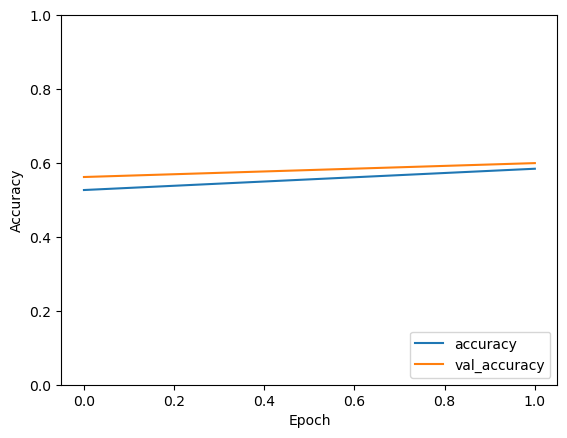

In [25]:
# Plot of learning curves for model [cnn]
plt.plot(history_cnn.history['accuracy'], label='accuracy')
plt.plot(history_cnn.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0, 1])
plt.legend(loc='lower right')

In [26]:
# loss function and accuracy on test set for model [cnn]
test_loss_cnn, test_acc_cnn = cnn.evaluate(test_images,  test_labels, verbose=2)

313/313 - 2s - 6ms/step - accuracy: 0.5807 - loss: 1.1901


In [27]:

# accuracy on test set for model [cnn]
print(test_acc_cnn)

0.5806999802589417


# 7.6 Further improvements.

How this result can be improved?

We can make some experiments involving:

- change number of the epochs,
- change number of the convolutional layers,
- change number and size of the kernels,
- change batch_size
- droput layer(s)
 (https://keras.io/api/layers/regularization_layers/dropout/),
- batch normalization
 (https://keras.io/api/layers/normalization_layers/batch_normalization/),
- transfer learning
 (https://keras.io/guides/transfer_learning/),
- data augmentation
(https://www.tensorflow.org/tutorials/images/data_augmentation?hl=en)